Cell 1: GPU Status Check

In [1]:
!nvidia-smi

Fri Apr 17 10:02:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Cell 2: Install Required Libraries

In [2]:
%pip -q install "ultralytics<=8.3.40" roboflow pandas numpy matplotlib pillow pyyaml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 898.5/898.5 kB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 84.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 135.4 MB/s eta 0:00:00


Cell 3: Core Library Imports & Setup

In [3]:
import os, random, shutil, zipfile, glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import yaml

from ultralytics import YOLO


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Cell 4: Extended Imports for Evaluation & Visualization

In [4]:
import ultralytics
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from ultralytics import YOLO
from roboflow import Roboflow
from sklearn.metrics import roc_curve, auc
from IPython.display import display, Image

Cell 5: Environment Verification

In [5]:
ultralytics.checks()
HOME = os.getcwd()
print("Working directory:", HOME)

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.3/112.6 GB disk)
Working directory: /content


Cell 6: Dataset Download from Roboflow

In [6]:
from roboflow import Roboflow

ROBOFLOW_API_KEY = ""
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

project = rf.workspace("").project("")
version = project.version(9)


dataset = version.download("yolov8")

print("Dataset location:", dataset.location)
print("data.yaml:", f"{dataset.location}/data.yaml")

loading Roboflow workspace...
loading Roboflow project...
Exporting format yolov8 in progress : 95.0%
Version export complete for yolov8 format



Extracting Dataset Version Zip to ML-hardware-tool-detection-dataset-9 in yolov8:: 100%|██████████| 24305/24305 [00:04<00:00, 5620.22it/s] 


Dataset location: /content/ML-hardware-tool-detection-dataset-9
data.yaml: /content/ML-hardware-tool-detection-dataset-9/data.yaml


Cell 7: Dataset Structure Inspection

In [7]:
data_yaml_path = Path(dataset.location) / "data.yaml"
assert data_yaml_path.exists(), "data.yaml not found"

with open(data_yaml_path, "r") as f:
    data_yaml = yaml.safe_load(f)

print("YAML keys:", list(data_yaml.keys()))
print("Classes:", data_yaml.get("nc"), " | names example:", (data_yaml.get("names") or [])[:5])

for split in ["train", "val", "test"]:
    p = Path(dataset.location) / split / "images"
    print(split, "->", p, "| exists:", p.exists())

YAML keys: ['names', 'nc', 'roboflow', 'test', 'train', 'val']
Classes: 24  | names example: ['Adjustable Wrench', 'Allen Key', 'Allen Key Set', 'Bolt', 'Brush']
train -> /content/ML-hardware-tool-detection-dataset-9/train/images | exists: True
val -> /content/ML-hardware-tool-detection-dataset-9/val/images | exists: False
test -> /content/ML-hardware-tool-detection-dataset-9/test/images | exists: True


Cell 8: Training Configuration

In [8]:
from pathlib import Path
from ultralytics import YOLO
import os
import pandas as pd

RUN_NAME = "yolo_hardware_run"
TASK = "detect"
EPOCHS = 50
IMGSZ = 640
BATCH = 16

run_dir_guess = Path("runs") / TASK / RUN_NAME
last_pt_guess = run_dir_guess / "weights" / "last.pt"
results_csv_guess = run_dir_guess / "results.csv"


resume_flag = False
if last_pt_guess.exists():
    resume_flag = True


if results_csv_guess.exists():
    try:
        df = pd.read_csv(results_csv_guess)
        if "epoch" in df.columns and df["epoch"].max() >= (EPOCHS - 1):
            resume_flag = False
            RUN_NAME = RUN_NAME + "_new"
            print("Previous run already finished. Starting NEW run:", RUN_NAME)
    except Exception as e:
        print("Could not read results.csv safely:", e)

print("Run name:", RUN_NAME)
print("Resume:", resume_flag)

model = YOLO("yolov8s.pt")

results = model.train(
    data=str(data_yaml_path),
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    name=RUN_NAME,
    task=TASK,
    plots=True,
    save=True,
    resume=resume_flag,
    seed=SEED,
    exist_ok=True
)

run_dir = Path(results.save_dir)
print("Training done. Using run_dir =", run_dir)

Run name: yolo_hardware_run
Resume: False


100%|██████████| 21.5M/21.5M [00:00<00:00, 220MB/s]


New https://pypi.org/project/ultralytics/8.4.38 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/ML-hardware-tool-detection-dataset-9/data.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=yolo_hardware_run, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=42, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=F

100%|██████████| 755k/755k [00:00<00:00, 27.2MB/s]


Overriding model.yaml nc=80 with nc=24

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1   1180672  ultralytic

...

      50/50      3.85G      0.499     0.2734      1.007         12        640: 100%|██████████| 634/634 [03:21<00:00,  3.14it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 32/32 [00:10<00:00,  3.02it/s]

                   all       1006       1103      0.965       0.97       0.98      0.892



50 epochs completed in 3.035 hours.
Optimizer stripped from runs/detect/yolo_hardware_run/weights/last.pt, 22.5MB
Optimizer stripped from runs/detect/yolo_hardware_run/weights/best.pt, 22.5MB

Validating runs/detect/yolo_hardware_run/weights/best.pt...
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 168 layers, 11,134,872 parameters, 0 gradients, 28.5 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 32/32 [00:12<00:00,  2.63it/s]


                   all       1006       1103      0.965       0.97      0.979      0.891
     Adjustable Wrench         49         51      0.975       0.98      0.987      0.932
             Allen Key         43         48          1      0.973      0.994      0.943
         Allen Key Set         46         46      0.976          1      0.995      0.926
                  Bolt         45         48      0.945      0.979      0.975      0.878
                 Brush         41         43      0.994          1      0.995      0.904
           Claw Hammer         43         43      0.986          1      0.995      0.911
        Cutting Pliers         47         49          1      0.976      0.995      0.961
  Flathead Screwdriver         41         41      0.853      0.951      0.967      0.874
              Hand Saw         44         44      0.992          1      0.995      0.935
                 Knife         47         47      0.994          1      0.995      0.892
                  Nai

Cell 9: Run Directory Selection

In [9]:
run_dir = Path("runs") / TASK / RUN_NAME
if not run_dir.exists():

    candidates = sorted(Path("runs").glob(f"{TASK}/*"), key=os.path.getmtime)
    print("Could not find exact run folder. Latest candidate:", candidates[-1] if candidates else None)
    run_dir = candidates[-1]

print("Using run dir:", run_dir)
print("Files:", [p.name for p in run_dir.glob("*")][:15])


Using run dir: runs/detect/yolo_hardware_run
Files: ['val_batch2_pred.jpg', 'val_batch1_labels.jpg', 'labels.jpg', 'R_curve.png', 'train_batch2.jpg', 'results.png', 'val_batch0_pred.jpg', 'events.out.tfevents.1776420239.a2231d7ceec5.2374.0', 'confusion_matrix_normalized.png', 'train_batch1.jpg', 'labels_correlogram.jpg', 'train_batch0.jpg', 'P_curve.png', 'results.csv', 'weights']


Cell 10: Artifact Directory Setup

In [10]:
paper_dir = Path("paper_artifacts")
fig_dir = paper_dir / "figures"
tab_dir = paper_dir / "tables"
raw_dir = paper_dir / "ultralytics_raw"

for d in [paper_dir, fig_dir, tab_dir, raw_dir]:
    d.mkdir(parents=True, exist_ok=True)


plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def savefig(path):
    path = Path(path)
    plt.tight_layout()
    plt.savefig(path, dpi=600, bbox_inches="tight", facecolor="white")
    plt.close()
    print("Saved:", path)

def copy_if_exists(src, dst_dir):
    src = Path(src)
    dst_dir = Path(dst_dir)
    if src.exists():
        shutil.copy(src, dst_dir / src.name)
        print("Copied:", src.name)

print("Folder is ready:", paper_dir)


Folder is ready: paper_artifacts


Cell 11: Copy YOLO Output Files

In [11]:
auto_plots = [
    "results.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "PR_curve.png",
    "P_curve.png",
    "R_curve.png",
    "F1_curve.png",
    "labels.jpg",
    "labels_correlogram.jpg",
    "results.csv",
]

for f in auto_plots:
    copy_if_exists(run_dir / f, raw_dir)

print("Copied available Ultralytics plots to:", raw_dir)


Copied: results.png
Copied: confusion_matrix.png
Copied: confusion_matrix_normalized.png
Copied: PR_curve.png
Copied: P_curve.png
Copied: R_curve.png
Copied: F1_curve.png
Copied: labels.jpg
Copied: labels_correlogram.jpg
Copied: results.csv
Copied available Ultralytics plots to: paper_artifacts/ultralytics_raw


Cell 12: Training Metrics Processing

In [12]:
results_csv = run_dir / "results.csv"
if not results_csv.exists():
    raise FileNotFoundError(f"results.csv not found in {run_dir}")

df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()
df.to_csv(tab_dir / "training_log_results.csv", index=False)


def pick_col(options):
    for c in options:
        if c in df.columns:
            return c
    return None

epoch = pick_col(["epoch"])
if epoch is None:
    df.insert(0, "epoch", np.arange(len(df)))
    epoch = "epoch"

# Metrics columns
prec = pick_col(["metrics/precision(B)", "metrics/precision"])
rec  = pick_col(["metrics/recall(B)", "metrics/recall"])
map50 = pick_col(["metrics/mAP50(B)", "metrics/mAP50"])
map5095 = pick_col(["metrics/mAP50-95(B)", "metrics/mAP50-95"])

# Loss columns
box_loss = pick_col(["train/box_loss"])
cls_loss = pick_col(["train/cls_loss"])
dfl_loss = pick_col(["train/dfl_loss"])

val_box = pick_col(["val/box_loss"])
val_cls = pick_col(["val/cls_loss"])
val_dfl = pick_col(["val/dfl_loss"])

# Precision/Recall
if prec and rec:
    plt.figure(figsize=(7,4))
    plt.plot(df[epoch], df[prec], label="Precision")
    plt.plot(df[epoch], df[rec],  label="Recall")
    plt.xlabel("Epoch"); plt.ylabel("Score")
    plt.title("Precision & Recall vs Epoch")
    plt.legend()
    savefig(fig_dir / "precision_recall_vs_epoch.png")

# mAP
if map50 and map5095:
    plt.figure(figsize=(7,4))
    plt.plot(df[epoch], df[map50], label="mAP@0.50")
    plt.plot(df[epoch], df[map5095], label="mAP@0.50:0.95")
    plt.xlabel("Epoch"); plt.ylabel("mAP")
    plt.title("mAP vs Epoch")
    plt.legend()
    savefig(fig_dir / "mAP_vs_epoch.png")

# Loss (train vs val)
loss_any = any([box_loss, cls_loss, dfl_loss])
if loss_any:
    plt.figure(figsize=(7,4))
    if box_loss: plt.plot(df[epoch], df[box_loss], label="train box_loss")
    if cls_loss: plt.plot(df[epoch], df[cls_loss], label="train cls_loss")
    if dfl_loss: plt.plot(df[epoch], df[dfl_loss], label="train dfl_loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title("Training Loss Components")
    plt.legend()
    savefig(fig_dir / "train_loss_components.png")

if any([val_box, val_cls, val_dfl]):
    plt.figure(figsize=(7,4))
    if val_box: plt.plot(df[epoch], df[val_box], label="val box_loss")
    if val_cls: plt.plot(df[epoch], df[val_cls], label="val cls_loss")
    if val_dfl: plt.plot(df[epoch], df[val_dfl], label="val dfl_loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title("Validation Loss Components")
    plt.legend()
    savefig(fig_dir / "val_loss_components.png")

print("Training curves saved into:", fig_dir)


Saved: paper_artifacts/figures/precision_recall_vs_epoch.png
Saved: paper_artifacts/figures/mAP_vs_epoch.png
Saved: paper_artifacts/figures/train_loss_components.png
Saved: paper_artifacts/figures/val_loss_components.png
Training curves saved into: paper_artifacts/figures


Cell 13: Class Distribution Analysis

In [13]:
# class names
names = data_yaml.get("names")
if isinstance(names, dict):
    names = [names[i] for i in range(len(names))]
if names is None:
    nc = int(data_yaml.get("nc", 0))
    names = [f"class_{i}" for i in range(nc)]

num_classes = len(names)
counts = np.zeros(num_classes, dtype=int)

label_files = glob.glob(str(Path(dataset.location) / "**" / "labels" / "*.txt"), recursive=True)
if len(label_files) == 0:
    raise FileNotFoundError("No YOLO label txt files found.")

for lf in label_files:
    with open(lf, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 1:
                cid = int(float(parts[0]))
                if 0 <= cid < num_classes:
                    counts[cid] += 1

dist_df = pd.DataFrame({"class_id": range(num_classes), "class_name": names, "num_labels": counts})
dist_df.to_csv(tab_dir / "dataset_label_distribution.csv", index=False)

# Plot
plt.figure(figsize=(10,4))
plt.bar(dist_df["class_name"], dist_df["num_labels"])
plt.xticks(rotation=60, ha="right")
plt.ylabel("Number of labeled instances")
plt.title("Dataset Label Distribution (Imbalance Check)")
savefig(fig_dir / "dataset_distribution.png")

print("Distribution saved and CSV saved.")


Saved: paper_artifacts/figures/dataset_distribution.png
Distribution saved and CSV saved.


Cell 14: Model Evaluation on Validation/Test Set

In [14]:
best_pt = run_dir / "weights" / "best.pt"
if not best_pt.exists():
    raise FileNotFoundError(f"best.pt not found at {best_pt}")

model_eval = YOLO(str(best_pt))

def run_eval(split):
    m = model_eval.val(
        data=str(data_yaml_path),
        imgsz=640,
        split=split,
        conf=0.25,
        iou=0.60,
        plots=True,
        save_json=True
    )
    return m

val_metrics = run_eval("val")
test_metrics = None
test_img_dir = Path(dataset.location) / "test" / "images"
if test_img_dir.exists():
    test_metrics = run_eval("test")

# Summary table
summary = []
summary.append({
    "split": "val",
    "precision": float(val_metrics.box.mp),
    "recall": float(val_metrics.box.mr),
    "mAP50": float(val_metrics.box.map50),
    "mAP50_95": float(val_metrics.box.map),
})

if test_metrics:
    summary.append({
        "split": "test",
        "precision": float(test_metrics.box.mp),
        "recall": float(test_metrics.box.mr),
        "mAP50": float(test_metrics.box.map50),
        "mAP50_95": float(test_metrics.box.map),
    })

summary_df = pd.DataFrame(summary)
summary_df.to_csv(tab_dir / "summary_metrics.csv", index=False)
print(summary_df)

for f in ["confusion_matrix.png", "confusion_matrix_normalized.png", "PR_curve.png", "P_curve.png", "R_curve.png", "F1_curve.png"]:
    copy_if_exists(run_dir / f, raw_dir)

print("Summary saved:", tab_dir / "summary_metrics.csv")


Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 168 layers, 11,134,872 parameters, 0 gradients, 28.5 GFLOPs


val: Scanning /content/ML-hardware-tool-detection-dataset-9/valid/labels.cache... 1006 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1006/1006 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 63/63 [00:15<00:00,  4.04it/s]


                   all       1006       1103      0.966      0.971      0.977      0.898
     Adjustable Wrench         49         51       0.98       0.98      0.989       0.94
             Allen Key         43         48          1      0.975      0.994      0.952
         Allen Key Set         46         46      0.979          1      0.995      0.929
                  Bolt         45         48      0.943      0.979      0.983      0.901
                 Brush         41         43          1          1      0.995      0.913
           Claw Hammer         43         43      0.985          1      0.995      0.921
        Cutting Pliers         47         49          1      0.977      0.995      0.965
  Flathead Screwdriver         41         41      0.851      0.951       0.96      0.876
              Hand Saw         44         44      0.991          1      0.995      0.941
                 Knife         47         47      0.994          1      0.995      0.905
                  Nai

val: Scanning /content/ML-hardware-tool-detection-dataset-9/test/labels... 1004 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1004/1004 [00:01<00:00, 592.73it/s]


val: New cache created: /content/ML-hardware-tool-detection-dataset-9/test/labels.cache


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 63/63 [00:15<00:00,  3.98it/s]


                   all       1004       1098       0.97      0.976      0.984      0.902
     Adjustable Wrench         28         33      0.971          1      0.992       0.94
             Allen Key         34         43      0.942      0.977      0.971      0.834
         Allen Key Set         46         46      0.978      0.957      0.977      0.929
                  Bolt         33         40       0.87          1      0.978      0.881
                 Brush         42         43          1      0.977      0.988       0.94
           Claw Hammer         36         36          1          1      0.995       0.97
        Cutting Pliers         50         52      0.981          1      0.995      0.985
  Flathead Screwdriver         52         52      0.894      0.975      0.956      0.891
              Hand Saw         47         47          1      0.979      0.989      0.902
                 Knife         44         44      0.989          1      0.995      0.902
                  Nai

(np.float64(-0.5), np.float64(2999.5), np.float64(2249.5), np.float64(-0.5))

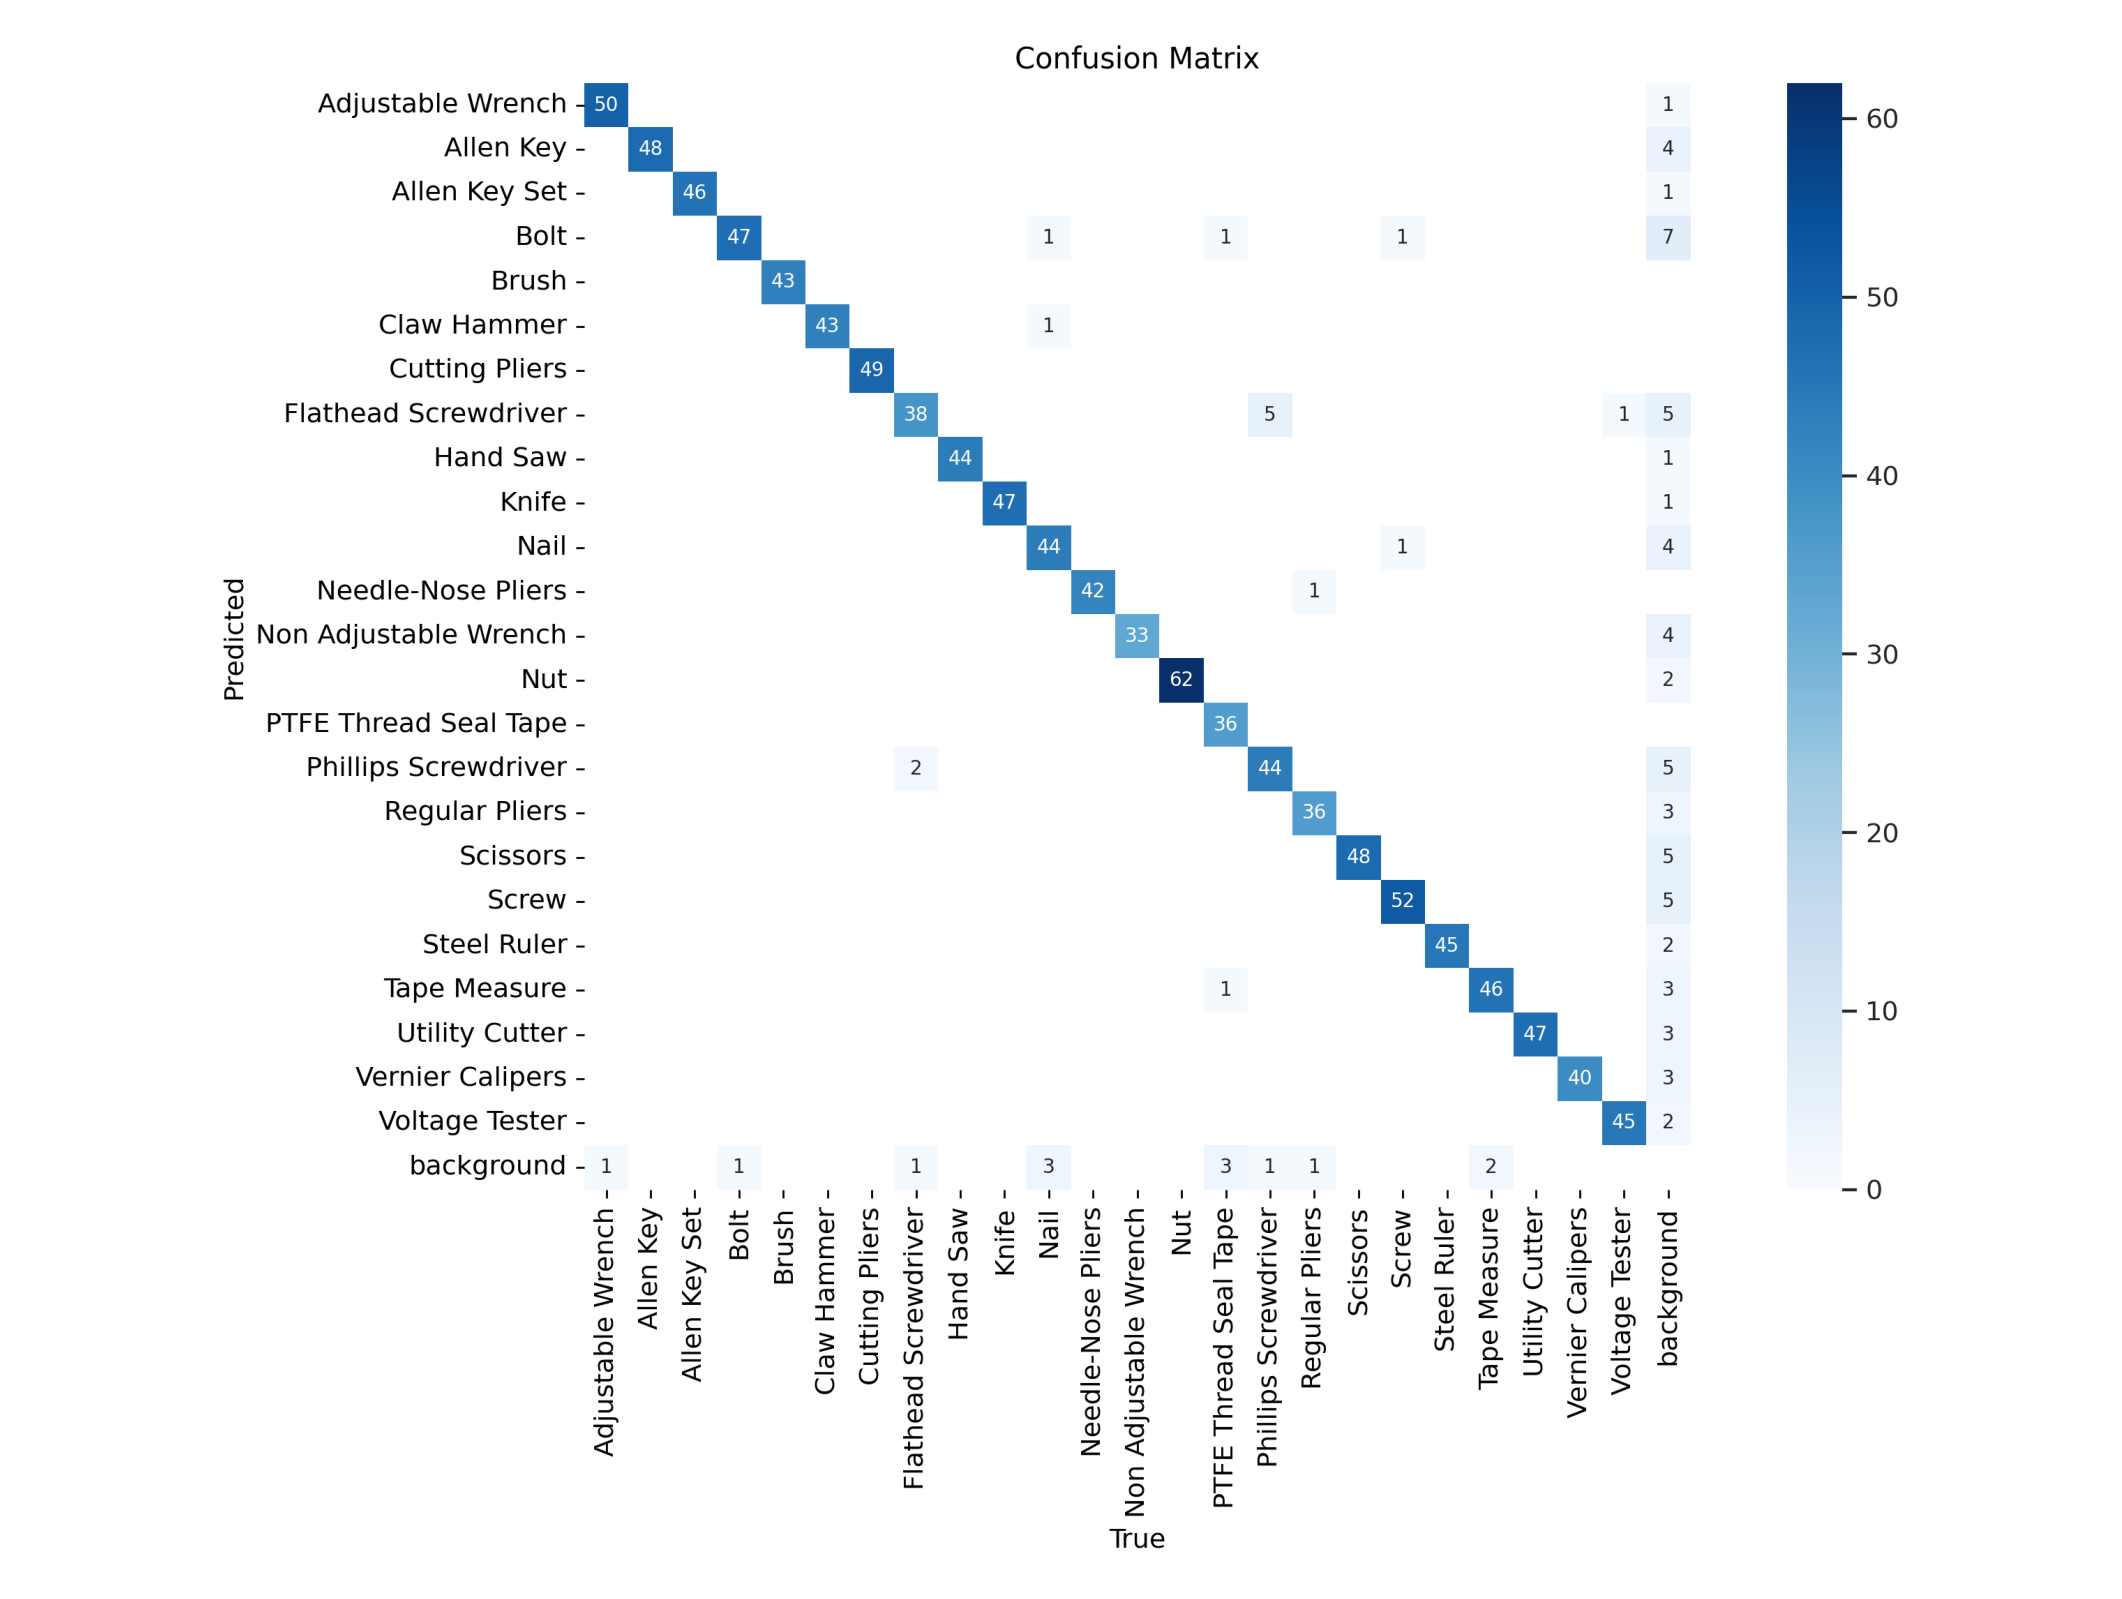

In [21]:
from PIL import Image
import matplotlib.pyplot as plt
import os

cm_path = os.path.join(run_dir, "confusion_matrix.png")

img = Image.open(cm_path)

plt.figure(figsize=(18, 15))
plt.imshow(img)
plt.axis('off')

Cell 15: Per-Class Performance Extraction

In [15]:
class_names = [model_eval.names[i] for i in range(len(model_eval.names))]

ap = np.array(val_metrics.box.ap)
ap50 = np.array(val_metrics.box.ap50) if hasattr(val_metrics.box, "ap50") else None

per_class = {
    "class_id": list(range(len(class_names))),
    "class_name": class_names,
    "AP50_95": ap.tolist(),
}

if ap50 is not None:
    per_class["AP50"] = ap50.tolist()

per_class_df = pd.DataFrame(per_class)
per_class_df.to_csv(tab_dir / "per_class_AP.csv", index=False)

print("Per-class AP saved:", tab_dir / "per_class_AP.csv")
per_class_df.head()


Per-class AP saved: paper_artifacts/tables/per_class_AP.csv


,class_id,class_name,AP50_95,AP50
0,0,Adjustable Wrench,0.939726,0.989216
1,1,Allen Key,0.952432,0.994200
2,2,Allen Key Set,0.928648,0.995000
3,3,Bolt,0.901099,0.983124
4,4,Brush,0.913176,0.995000


Cell 16: Prediction Visualization

In [16]:
import math


val_images_dir = Path(dataset.location) / "val" / "images"
if not val_images_dir.exists():
    val_images_dir = Path(dataset.location) / "train" / "images"

img_paths = []
for ext in ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"]:
    img_paths += list(val_images_dir.glob(ext))

if len(img_paths) == 0:
    raise FileNotFoundError(f"No images found in {val_images_dir}")

random.shuffle(img_paths)
sample_paths = img_paths[:12]

pred = model_eval.predict(
    source=[str(p) for p in sample_paths],
    imgsz=640,
    conf=0.25,
    iou=0.60,
    save=False,
    verbose=False
)


cols = 4
rows = math.ceil(len(pred)/cols)

plt.figure(figsize=(cols*4, rows*4))
for i, r in enumerate(pred):
    im = r.plot()
    plt.subplot(rows, cols, i+1)
    plt.imshow(im)
    plt.axis("off")
plt.suptitle("Qualitative Predictions (YOLO)", y=0.92)
savefig(fig_dir / "qualitative_predictions_grid.png")


Saved: paper_artifacts/figures/qualitative_predictions_grid.png


Cell 17: Export Processed Artifacts

In [17]:
zip_path = Path("paper_artifacts.zip")
if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for p in paper_dir.rglob("*"):
        z.write(p, p.relative_to(paper_dir.parent))

print("Created ZIP:", zip_path)

from google.colab import files
files.download(str(zip_path))


Created ZIP: paper_artifacts.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Cell 18: Export Full YOLO Run Outputs

In [18]:
import shutil
from google.colab import files


folder_path = "/content/runs"
zip_name = "run_file"

shutil.make_archive(zip_name, 'zip', folder_path)

files.download(zip_name + ".zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>